In [1]:
#import libraries
import pandas as pd
import numpy as np

In [2]:
#load the dataset
df = pd.read_csv("C:/Users/shash/Desktop/D/Labmentix/Project 9/online_retail.csv")

In [ ]:
#PHASE 1 - DATA CLEANING

In [3]:
#check dataset column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [4]:
#check for null values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
#remove missing customer id
df=df.dropna(subset=["CustomerID"])

In [6]:
#remove cancelled order
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [7]:
#remove invalid records
df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
]

In [8]:
#create total amount
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [9]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

In [ ]:
#PHASE 2 - EDA

In [17]:
%pip install matplotlib seaborn

  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --------- ------------------------------ 2.1/9.3 MB 9.8 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.3 MB 9.4 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.3 MB 9.1 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 8.6 MB/s  0:00:01
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.4 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 6.4 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----------- ---------------------------- 2/7 [fonttools]


In [10]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
#transaction by country
country_sales = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False)

<Axes: xlabel='Country', ylabel='TotalAmount'>

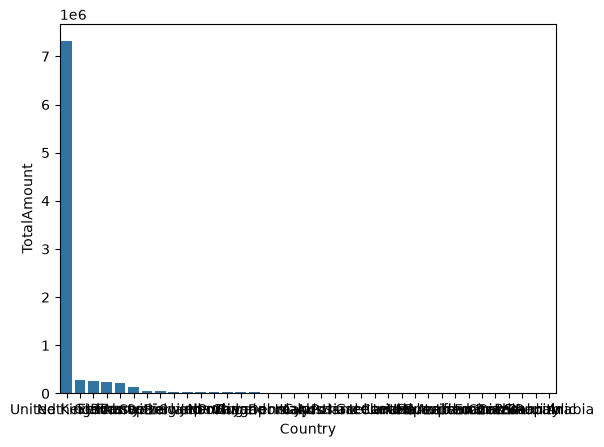

In [12]:
sns.barplot(country_sales)

In [13]:
#top selling products
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

<Axes: xlabel='Description', ylabel='Quantity'>

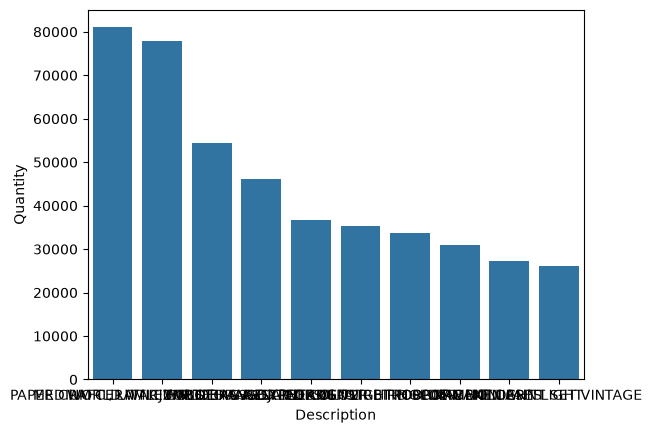

In [14]:
sns.barplot(top_products)

In [16]:
#convert to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [18]:
#now create month
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [19]:
#monthly sales trend
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["TotalAmount"]
    .sum()
)

In [21]:
print(df["InvoiceDate"].head())
print(df["InvoiceDate"].dtype)

0   2022-12-01 08:26:00
1   2022-12-01 08:26:00
2   2022-12-01 08:26:00
3   2022-12-01 08:26:00
4   2022-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[us]
datetime64[us]


<Axes: xlabel='TotalAmount', ylabel='Count'>

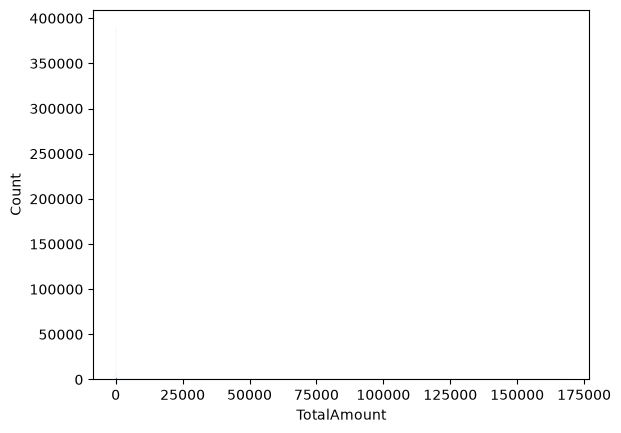

In [31]:
#revenue distribution
sns.histplot(df["TotalAmount"])

In [ ]:
#PHASE 3 - RFM ANALYSIS

In [23]:
#regency - latest date
snapshot_date = df["InvoiceDate"].max()

In [24]:
#customer last purchase
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

In [25]:
#renames
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [29]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetary'], dtype='str')

#PHASE 4 - SCALING

In [31]:
%pip install scikit-learn

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 10.5 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.3 MB 10.4 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 9.7 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 8.8 MB/s  0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   -----

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [34]:
import joblib

In [35]:
#save scalar
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [ ]:
#PHASE 5- FIND BEST CLUSTERS

In [38]:
from sklearn.cluster import KMeans

In [39]:
#elbow method
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

In [40]:
#silhouette score
from sklearn.metrics import silhouette_score
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

In [ ]:
#PHASE 6- CUSTOMER SEGMENTATION

In [41]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [42]:
#save model
joblib.dump(
    kmeans,
    "customer_segment_model.pkl"
)

['customer_segment_model.pkl']

In [ ]:
#PHASE 7- cluster implementation

In [43]:
cluster_profile = rfm.groupby(
    "Cluster"
)[["Recency","Frequency","Monetary"]].mean()

In [44]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,42.702685,3.682711,1359.049284
1,247.075914,1.552015,480.617480
2,6.384615,82.538462,127338.313846
3,14.500000,22.333333,12709.090490


In [45]:
#create mapping
segment_map = {
    0:"High Value",
    1:"Regular",
    2:"At Risk",
    3:"Occasional"
}

In [46]:
segment_map

{0: 'High Value', 1: 'Regular', 2: 'At Risk', 3: 'Occasional'}

In [ ]:
#PHASE 8-CLUSTER VISULAIZATION

In [48]:
import plotly.express as px

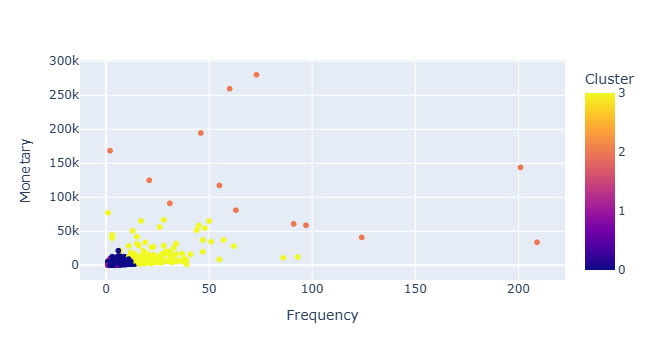

In [49]:
#2D scatter
px.scatter(
    rfm,
    x="Frequency",
    y="Monetary",
    color="Cluster"
)

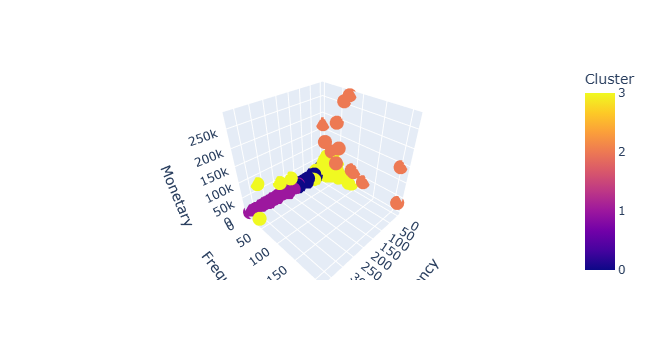

In [50]:
#3D plot
px.scatter_3d(
    rfm,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color="Cluster"
)

In [ ]:
#PHASE 9- Recommendation system - this is second ML component

In [51]:
#create customer product matrix
customer_product = pd.pivot_table(
    df,
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

In [52]:
customer_product

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18281.0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
18282.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
#transpose
product_matrix = customer_product.T

In [54]:
#cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(
    product_matrix
)

In [55]:
similarity_df = pd.DataFrame(
    similarity,
    index=product_matrix.index,
    columns=product_matrix.index
)

In [56]:
#recommendation function
def recommend_products(product_name):

    similar = similarity_df[
        product_name
    ].sort_values(
        ascending=False
    )

    recommendations = similar.iloc[1:6]

    return recommendations.index.tolist()

In [59]:
recommend_products(
    "WHITE HANGING HEART T-LIGHT HOLDER"
)

['GIN + TONIC DIET METAL SIGN',
 'RED HANGING HEART T-LIGHT HOLDER',
 'WASHROOM METAL SIGN',
 'LAUNDRY 15C METAL SIGN',
 'GREEN VINTAGE SPOT BEAKER']